**Vorticity example** 
    
- data from Kutz et al: Dynamic Mode Decomposition (book) (http://dmdbook.com/)

In [1]:
%run Streaming_DMD_functions.ipynb 

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [3]:
mat = scipy.io.loadmat('CYLINDER_ALL.mat')
print(mat.keys())
u=mat['UALL']
v=mat['VALL']
vort=mat['VORTALL']

del mat
del u
del v

nx=199; ny=449

dict_keys(['__header__', '__version__', '__globals__', 'UALL', 'UEXTRA', 'VALL', 'VEXTRA', 'VORTALL', 'VORTEXTRA', 'm', 'n', 'nx', 'ny'])


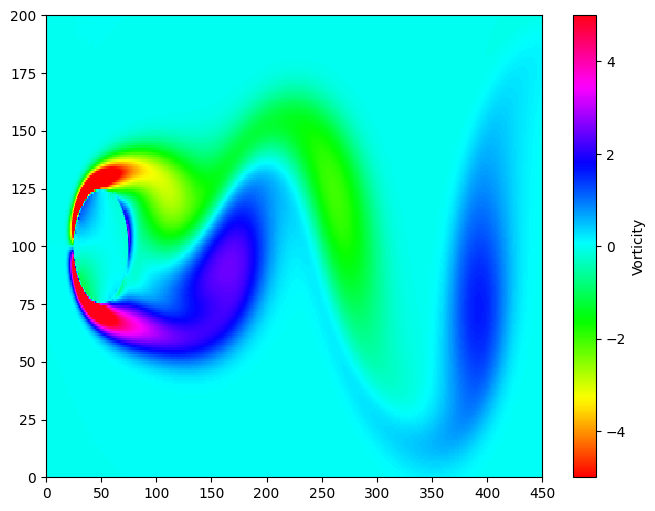

In [4]:
koji=0

vort1=vort[:,koji]

vort1 = vort1

fig, ax = plt.subplots(figsize=(8, 6))
y_os = np.linspace(0,200,200)
x_os = np.linspace(0,450,450)

c = ax.pcolormesh(x_os, y_os, vort1.reshape((-1,199)).T, cmap='hsv', vmin=-5, vmax=5)
fig.colorbar(c, ax=ax, label='Vorticity')



In [ ]:
def Addxy_compress_force(Qx, Qy, Qxy, Gyx, Gx, Gy, x, y, X_t, Y_t, r0=0, tol1=1e-6, tol2=1e-1, tol3 = 1e-8, svd=False):    
    """
    HWR-sDMD in two bases with forced compression to maximum rank r0 
    and simultaneous updates to \widetilde X_t and \widetilde Y_t (done for figure 1).
    """

    rx=Qx.shape[1]; ry=Qy.shape[1]; m=x.shape[0]

    #GS procedure
    q1, xtilde, gammax = GS_reorth(Qx, x, tol1, tol2)
    q2, ytilde, gammay = GS_reorth(Qy, y, tol1, tol2)

    # update Gyx and Gx
    Gyx += ytilde * xtilde.T 
    Gx += xtilde * xtilde.T
    Gy += ytilde * ytilde.T

    X_t = np.bmat([[X_t, xtilde]])
    Y_t = np.bmat([[Y_t, ytilde]])
    
    #expansion of basis (if necessary)
    if gammax > 0:
        if gammay > 0:
            Qxy = np.bmat([[Qxy, Qx.T@q2], [q1.T@Qy, q1.T@q2]])
            Qx = np.bmat([Qx, q1.reshape(-1,1)])
            Qy = np.bmat([Qy, q2.reshape(-1,1)])
            Gyx = np.bmat([[Gyx, ytilde*gammax], [gammay*xtilde.T, np.array([[gammay*gammax]])]])
            Gy = np.bmat([[Gy, ytilde*gammay], [gammay*ytilde.T, np.array([[gammay**2]])]])
            Gx = np.bmat([[Gx, xtilde*gammax], [gammax*xtilde.T, np.array([[gammax**2]])]]) 
            xnew = np.vstack((np.zeros((X_t.shape[1]-1,1)), gammax))
            X_t = np.vstack((X_t, xnew.T))
            ynew = np.vstack((np.zeros((Y_t.shape[1]-1,1)), gammay))
            Y_t = np.vstack((Y_t, ynew.T))
            ry+=1
        else:
            Qxy = np.bmat([[Qxy], [q1.T@Qy]])
            Qx = np.bmat([Qx, q1.reshape(-1,1)])
            Gyx = np.bmat([Gyx, ytilde*gammax])
            Gx = np.bmat([[Gx, xtilde*gammax], [gammax*xtilde.T, np.array([[gammax**2]])]]) 
            xnew = np.vstack((np.zeros((X_t.shape[1]-1,1)), gammax))
            X_t = np.vstack((X_t, xnew.T))
        rx+=1
    elif gammay > 0:
        Qxy = np.bmat([Qxy, Qx.T@q2])
        Qy = np.bmat([Qy, q2.reshape(-1,1)])
        Gyx = np.bmat([[Gyx],[gammay*xtilde.T]])
        Gy = np.bmat([[Gy, ytilde*gammay], [gammay*ytilde.T, np.array([[gammay**2]])]])
        ynew = np.vstack((np.zeros((Y_t.shape[1]-1,1)), gammay))
        Y_t = np.vstack((Y_t, ynew.T))
        ry += 1
    
    #compression
    if r0 and not svd:
        if rx == r0:
            evals, evecs = np.linalg.eigh(Gx, 'U')
            idx = np.argsort(np.abs(evals))[::-1] #in case the property of symmetry was lost
            first=idx[0]
            rho=r0
            for i in range(1, r0):
                if(evals[idx[i]]<=evals[first]*tol3):
                    rho = i
                    break
            if(rho<r0):
                idx = idx[:rho]
                qx = np.asmatrix(evecs[:, idx])
                Qx = Qx * qx
                Gyx = Gyx * qx
                Qxy = qx.T * Qxy 
                X_t = qx.T * X_t
                Gx = np.asmatrix(np.diag(evals[idx]))
            else:
                print("Gx shouldn't be compressed!")
                rho = r0-1
                idx = idx[:rho]
                qx = np.asmatrix(evecs[:, idx])
                Qx = Qx * qx
                Gyx = Gyx * qx
                Qxy = qx.T * Qxy 
                X_t = qx.T * X_t
                Gx = np.asmatrix(np.diag(evals[idx]))
        if ry == r0:
            evals, evecs = np.linalg.eigh(Gy, 'U')
            idx = np.argsort(evals)[::-1]
            first=idx[0]
            rho=r0
            for i in range(1, r0):
                if(evals[idx[i]]<=evals[first]*tol3):
                    rho = i
                    break
            if(rho < r0):
                idx = idx[:rho]
                qy = np.asmatrix(evecs[:, idx])
                Qy = Qy * qy
                Gyx = qy.T * Gyx
                Qxy = Qxy * qy 
                Y_t = qy.T * Y_t
                Gy = np.asmatrix(np.diag(evals[idx]))
            else:
                print("Gy shouldn't be compressed!")
                rho = r0-1
                idx = idx[:rho]
                qy = np.asmatrix(evecs[:, idx])
                Qy = Qy * qy
                Gyx = qy.T * Gyx
                Qxy = Qxy * qy 
                Y_t = qy.T * Y_t
                Gy = np.asmatrix(np.diag(evals[idx]))

    if r0 and svd:
        if rx == r0:
            u, s, v = np.linalg.svd(X_t)
            first=s[0]
            rho=r0
            for i in range(1, r0):
                if(s[i]<=first*tol3):
                    rho = i
                    break
            if(rho<r0):
                qx = u[:, :rho]
                Qx = Qx * qx
                Gyx = Gyx * qx
                Qxy = qx.T * Qxy 
                X_t = np.diag(s[:rho])@v[:rho, :]
                Gx = np.asmatrix(np.diag(s[:rho]**2))
            else:
                print("Gx shouldn't be compressed! ")
                rho = r0-1
                qx = u[:, :rho]
                Qx = Qx * qx
                Gyx = Gyx * qx
                Qxy = qx.T * Qxy #DODATI
                X_t = np.diag(s[:rho])@v[:rho, :]
                Gx = np.asmatrix(np.diag(s[:rho]**2))
        if ry == r0:
            u, s, v = np.linalg.svd(Y_t)
            first=s[0]
            rho=r0
            for i in range(1, r0):
                if(s[i]<=first*tol3):
                    rho = i
                    break
            if(rho < r0):
                qy = u[:, :rho]
                Qy = Qy * qy
                Gyx = qy.T * Gyx
                Qxy = Qxy * qy #DODATI
                Y_t = np.diag(s[:rho])@v[:rho, :]
                Gy = np.asmatrix(np.diag(s[:rho]**2))
            else:
                print("Gy shouldn't be compressed!")
                rho = r0-1
                qy = u[:, :rho]
                Qy = Qy * qy
                Gyx = qy.T * Gyx
                Qxy = Qxy * qy #DODATI
                Y_t = np.diag(s[:rho])@v[:rho, :]
                Gy = np.asmatrix(np.diag(s[:rho]**2))

    return Qx, Qy, Qxy, Gyx, Gx, Gy, X_t, Y_t


In [14]:
############################################################################################################
####        r = 30
############################################################################################################
m=vort.shape[1]

poc = 2
ordd = "fro"


U_x, Sigmax, Vx = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
X_tilda = np.diag(Sigmax)@Vx
U_y, Sigmay, Vy = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
Y_tilda = np.diag(Sigmay)@Vy

Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T


x=vort[:,poc-1:poc]

Qxy = U_x.T@U_y

rec_x = []
rec_y = []
qx_ort = []
qy_ort = []
cond_gx = []
cond_gyx = []
cond_qxy = []
cond_qaq = []

rec_x.append(np.linalg.norm((vort[:, :poc-1] - U_x @ X_tilda), ord=ordd)/np.linalg.norm(vort[:, :poc-1], ord=ordd))
rec_y.append(np.linalg.norm(vort[:, 1:poc] - U_y @ Y_tilda, ord=ordd)/np.linalg.norm(vort[:, 1:poc], ord=ordd))
qx_ort.append(np.linalg.norm(U_x.T@U_x - np.eye(U_x.shape[1]), ord=ordd))
qy_ort.append(np.linalg.norm(U_y.T@U_y - np.eye(U_y.shape[1]), ord=ordd))
cond_gx.append(np.linalg.cond(Gx))
cond_gyx.append(np.linalg.cond(Gyx))
cond_qxy.append(np.linalg.cond(Qxy))
cond_qaq.append(np.linalg.cond(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T)))


tol11 = 1e-6; tol22=1e-1; tol33 = 1e-12
for i in range(poc, 151-1, 1): 

    y=vort[:,i:(i+1)]
                                                                                        
    U_x, U_y, Qxy, Gyx, Gx, Gy, X_tilda, Y_tilda = Addxy_compress_force(U_x, U_y, Qxy, Gyx, Gx, Gy, x, y,  X_tilda, Y_tilda,
                                                         r0=30, tol1=tol11, tol2=tol22, tol3 = tol33, svd=False)
    rec_x.append(np.linalg.norm(vort[:, :i] - U_x @ X_tilda, ord=ordd)/np.linalg.norm(vort[:, :i], ord=ordd))
    rec_y.append(np.linalg.norm(vort[:, 1:i+1] - U_y @ Y_tilda, ord=ordd)/np.linalg.norm(vort[:, 1:i+1], ord=ordd))
    qx_ort.append(np.linalg.norm(U_x.T@U_x - np.eye(U_x.shape[1]), ord=ordd))
    qy_ort.append(np.linalg.norm(U_y.T@U_y - np.eye(U_y.shape[1]), ord=ordd))
    cond_gx.append(np.linalg.cond(Gx))
    cond_gyx.append(np.linalg.cond(Gyx))
    cond_qxy.append(np.linalg.cond(Qxy))
    cond_qaq.append(np.linalg.cond(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T)))

    x=y


Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be compressed!
Gx shouldn't be compressed!
Gy shouldn't be comp

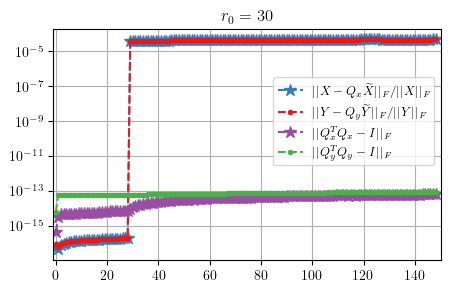

In [15]:
plt.rcParams['text.usetex'] = True

plt.figure(figsize=(5, 3))
plt.plot(rec_x, ls="--", marker="*", label="$||X - Q_x\widetilde X||_F/||X||_F$", c=CB_color_cycle[0], markersize=9)
plt.plot(rec_y, ls="--", marker=".", label="$||Y - Q_y\widetilde Y||_F/||Y||_F$", c=CB_color_cycle[7])
plt.plot(qx_ort, ls="--", marker="*", label="$||Q_x^TQ_x - I||_F$", c=CB_color_cycle[5], markersize=9)
plt.plot(qy_ort, ls="--", marker=".", label="$||Q_y^TQ_y - I||_F$", c=CB_color_cycle[2])
plt.yscale("log")
plt.legend(fontsize=9, bbox_to_anchor = (0.55,0.6))
#plt.title("$r_0 = 30, \mathrm{tol}_1 = {}, \mathrm{tol}_2 = {}, \mathrm{tol}_3 = {}$".format(tol11, tol22, tol33))
plt.title("$r_0 = 30$")
plt.xlim(-1,150)

plt.grid()

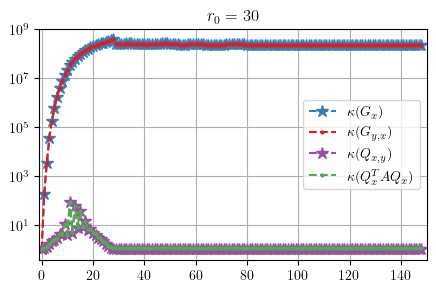

In [16]:
plt.figure(figsize=(5, 3))
plt.plot(cond_gx, ls="--", marker="*", label="$\kappa(G_x)$", c=CB_color_cycle[0], markersize=9)
plt.plot(cond_gyx, ls="--", marker=".", label="$\kappa(G_{y,x})$", c=CB_color_cycle[7], markersize=4)
plt.plot(cond_qxy, ls="--", marker="*", label="$\kappa(Q_{x,y})$", c=CB_color_cycle[5], markersize=9)
plt.plot(cond_qaq, ls="--", marker=".", label="$\kappa(Q_x^TAQ_x)$", c=CB_color_cycle[2], markersize=4)
plt.title("$r_0 = 30$")
plt.yscale("log")
plt.legend()
plt.xlim(-1,150)
plt.grid()

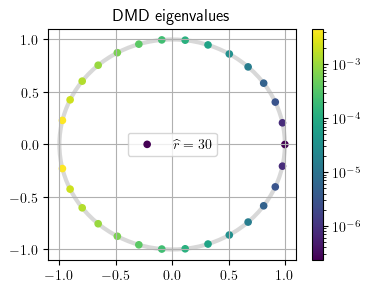

In [17]:
plt.figure(figsize=(4,3))
plt.tight_layout(pad=1.08)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), zorder=1, c="gray", alpha=0.3, lw=3)

_, Wh, Lh = DMD_compress(U_x, Qxy, Gyx, Gx, uw=True)
res = np.linalg.norm((U_y@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T))@Wh - (U_x@Wh)@np.diag(Lh), axis=0)

scatter = plt.scatter(np.real(Lh), np.imag(Lh), ls="", marker="o", label="$\widehat r=30$", c=res, norm=colors.LogNorm(), s=20)
plt.colorbar(scatter, cmap='viridis')
plt.title("DMD eigenvalues")
plt.grid()

plt.legend()

In [18]:
############################################################################################################
####        r = 100
############################################################################################################
m=vort.shape[1]

poc = 2
ordd = "fro"


U_x, Sigmax, Vx = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
X_tilda = np.diag(Sigmax)@Vx
U_y, Sigmay, Vy = np.linalg.svd(vort[:,1:poc],full_matrices=False) 
Y_tilda = np.diag(Sigmay)@Vy

Gyx = Y_tilda@X_tilda.T; Gx=X_tilda@X_tilda.T; Gy = Y_tilda@Y_tilda.T

x=vort[:,poc-1:poc]

Qxy = U_x.T@U_y

rec_x = []
rec_y = []
qx_ort = []
qy_ort = []
cond_gx = []
cond_gyx = []
cond_qxy = []
cond_qaq = []

rec_x.append(np.linalg.norm((vort[:, :poc-1] - U_x @ X_tilda), ord=ordd)/np.linalg.norm(vort[:, :poc-1], ord=ordd))
rec_y.append(np.linalg.norm(vort[:, 1:poc] - U_y @ Y_tilda, ord=ordd)/np.linalg.norm(vort[:, 1:poc], ord=ordd))
qx_ort.append(np.linalg.norm(U_x.T@U_x - np.eye(U_x.shape[1]), ord=ordd))
qy_ort.append(np.linalg.norm(U_y.T@U_y - np.eye(U_y.shape[1]), ord=ordd))
cond_gx.append(np.linalg.cond(Gx))
cond_gyx.append(np.linalg.cond(Gyx))
cond_qxy.append(np.linalg.cond(Qxy))
cond_qaq.append(np.linalg.cond(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T)))


tol11 = 1e-6; tol22=1e-1; tol33 = 1e-12
for i in range(poc, 151-1, 1): 

    y=vort[:,i:(i+1)]
                                                                                        
    U_x, U_y, Qxy, Gyx, Gx, Gy, X_tilda, Y_tilda = Addxy_compress_force(U_x, U_y, Qxy, Gyx, Gx, Gy, x, y,  X_tilda, Y_tilda,
                                                         r0=100, tol1=tol11, tol2=tol22, tol3 = tol33, svd=False)
    rec_x.append(np.linalg.norm(vort[:, :i] - U_x @ X_tilda, ord=ordd)/np.linalg.norm(vort[:, :i], ord=ordd))
    rec_y.append(np.linalg.norm(vort[:, 1:i+1] - U_y @ Y_tilda, ord=ordd)/np.linalg.norm(vort[:, 1:i+1], ord=ordd))
    qx_ort.append(np.linalg.norm(U_x.T@U_x - np.eye(U_x.shape[1]), ord=ordd))
    qy_ort.append(np.linalg.norm(U_y.T@U_y - np.eye(U_y.shape[1]), ord=ordd))
    cond_gx.append(np.linalg.cond(Gx))
    cond_gyx.append(np.linalg.cond(Gyx))
    cond_qxy.append(np.linalg.cond(Qxy))
    cond_qaq.append(np.linalg.cond(Qxy@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T)))

    x=y


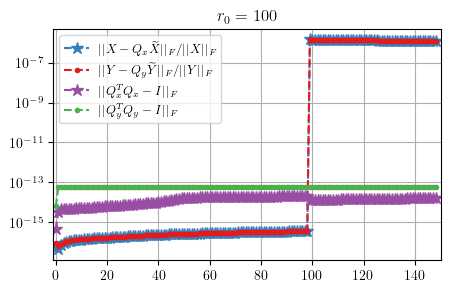

In [19]:
plt.rcParams['text.usetex'] = True

plt.figure(figsize=(5, 3))
plt.plot(rec_x, ls="--", marker="*", label="$||X - Q_x\widetilde X||_F/||X||_F$", c=CB_color_cycle[0], markersize=9)
plt.plot(rec_y, ls="--", marker=".", label="$||Y - Q_y\widetilde Y||_F/||Y||_F$", c=CB_color_cycle[7])
plt.plot(qx_ort, ls="--", marker="*", label="$||Q_x^TQ_x - I||_F$", c=CB_color_cycle[5], markersize=9)
plt.plot(qy_ort, ls="--", marker=".", label="$||Q_y^TQ_y - I||_F$", c=CB_color_cycle[2])
plt.yscale("log")
plt.legend(fontsize=9)
#plt.title("$r_0 = 100, \mathrm{tol}_1 = {}, \mathrm{tol}_2 = {}, \mathrm{tol}_3 = {}$".format(tol11, tol22, tol33))
plt.title("$r_0 = 100$")
plt.xlim(-1,150)

plt.grid()

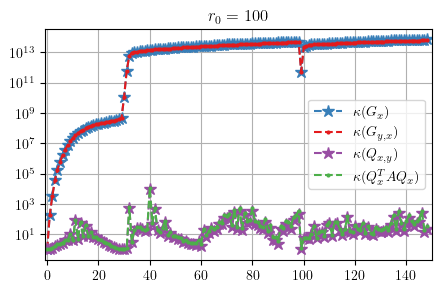

In [20]:
plt.figure(figsize=(5, 3))
plt.plot(cond_gx, ls="--", marker="*", label="$\kappa(G_x)$", c=CB_color_cycle[0], markersize=9)
plt.plot(cond_gyx, ls="--", marker=".", label="$\kappa(G_{y,x})$", c=CB_color_cycle[7], markersize=4)
plt.plot(cond_qxy, ls="--", marker="*", label="$\kappa(Q_{x,y})$", c=CB_color_cycle[5], markersize=9)
plt.plot(cond_qaq, ls="--", marker=".", label="$\kappa(Q_x^TAQ_x)$", c=CB_color_cycle[2], markersize=4)
#plt.title("$r_0 = 100, \mathrm{tol}_1 = {}, \mathrm{tol}_2 = {}, \mathrm{tol}_3 = {}$".format(tol11, tol22, tol33))
plt.title("$r_0 = 100$")
plt.yscale("log")
plt.legend()
plt.xlim(-1,150)
plt.grid()

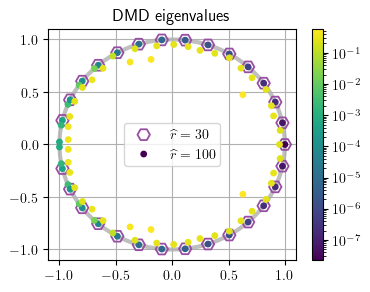

In [21]:
plt.figure(figsize=(4,3))
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), lw=3, zorder=1, color="gray", alpha=0.5)

plt.scatter(np.real(Lh), np.imag(Lh), marker='H', label="$\widehat r = 30$", s=80, color=CB_color_cycle[5], zorder=2, facecolor="None", lw=1.3)

_, W, L = DMD_compress(U_x, Qxy, Gyx, Gx, uw=True)
res = np.linalg.norm((U_y@(scipy.linalg.solve(Gx.T, Gyx.T, assume_a='her').T))@W - (U_x@W)@np.diag(L), axis=0)

scatter = plt.scatter(np.real(L), np.imag(L), ls="", marker="o", label="$\widehat r=100$", c=res, norm=colors.LogNorm(), s=15, zorder=3)
plt.colorbar(scatter)
plt.title("DMD eigenvalues")
plt.grid()
plt.legend()